# Assignment 3: Data Visualization

### Data Loading and Cleaning

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

FILE_PATH = 'EmergencyTriageDataset_Reduced_Dirty.csv'
df = pd.read_csv(FILE_PATH)

# ── Apply all cleaning from Days 1 & 2 ───────────────────────

# Gender
gender_map = {'Male': 1, 'MALE': 1, '1': 1, 'Female': 0, 'FEMALE': 0, '0': 0}
df['Gender'] = df['Gender'].map(gender_map)

# GCS
df['GCS'] = pd.to_numeric(df['GCS'], errors='coerce')
df.loc[(df['GCS'] < 3) | (df['GCS'] > 15), 'GCS'] = np.nan
df['GCS'] = df['GCS'].fillna(df['GCS'].median())

# SBP
df['SBP'] = pd.to_numeric(df['SBP'], errors='coerce')
df.loc[(df['SBP'] < 50) | (df['SBP'] > 250), 'SBP'] = np.nan
df['SBP'] = df['SBP'].fillna(df['SBP'].median())

# DBP
df['DBP'] = pd.to_numeric(df['DBP'], errors='coerce')
df.loc[(df['DBP'] < 30) | (df['DBP'] > 150), 'DBP'] = np.nan
df['DBP'] = df['DBP'].fillna(df['DBP'].median())

# Pulse
df['pulse'] = pd.to_numeric(df['pulse'], errors='coerce')
df.loc[(df['pulse'] < 20) | (df['pulse'] > 250), 'pulse'] = np.nan
df['pulse'] = df['pulse'].fillna(df['pulse'].median())

# Temp
def to_celsius(val):
    if pd.isnull(val): return np.nan
    s = str(val).strip()
    try:
        if s.endswith('C'): return float(s[:-1])
        elif s.endswith('F'): return (float(s[:-1]) - 32) * 5/9
        else: return float(s)
    except: return np.nan

df['Temp'] = df['Temp'].apply(to_celsius)
df.loc[(df['Temp'] < 32) | (df['Temp'] > 43), 'Temp'] = np.nan
df['Temp'] = df['Temp'].fillna(df['Temp'].median())

# RR
df['RR'] = pd.to_numeric(df['RR'], errors='coerce')
df.loc[(df['RR'] < 5) | (df['RR'] > 60), 'RR'] = np.nan
df['RR'] = df['RR'].fillna(df['RR'].median())

# FiO2
df['Fio2'] = pd.to_numeric(df['Fio2'], errors='coerce')
df['Fio2'] = df['Fio2'].fillna(df['Fio2'].median())  # 100% is clinically valid — no range filter

# MAP
df['MAP'] = pd.to_numeric(df['MAP'], errors='coerce')
df['MAP_Calc'] = (df['SBP'] + 2 * df['DBP']) / 3
df['MAP'] = df['MAP'].fillna(df['MAP_Calc'])
df = df.drop(columns=['MAP_Calc'])

print(f"Clean dataset: {df.shape[0]} rows x {df.shape[1]} columns")
print(f"Total NaNs remaining: {df.isnull().sum().sum()}")
df.head()

Clean dataset: 2205 rows x 11 columns
Total NaNs remaining: 0


,ID,Age,Gender,GCS,SBP,DBP,MAP,pulse,Temp,RR,Fio2
0,1,34,0,15.0,93.0,67.0,75.67,128.0,36.8,14.0,21.0
1,2,20,1,15.0,130.0,90.0,103.33,80.0,37.0,16.0,21.0
2,3,77,0,14.0,163.0,105.0,124.33,92.0,36.8,18.0,21.0
3,4,23,0,8.0,100.0,60.0,73.33,100.0,37.0,12.0,100.0
4,5,86,0,15.0,150.0,90.0,110.00,85.0,37.0,19.0,21.0


#### Plot 1 (Histogram): What is the distribution of respiratory rates among patients, and how many fall outside the normal respiratory range?

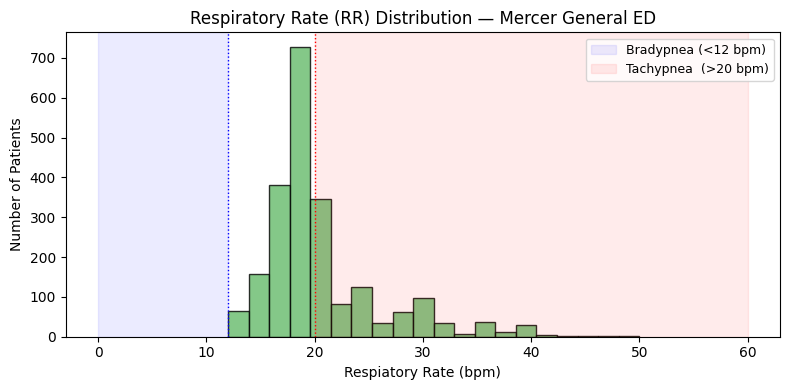

Saved: RR_histogram.png


In [3]:
# Histogram: RR (Respiratory rate) distribution
fig, ax = plt.subplots(figsize=(8, 4))

ax.hist(df['RR'], bins=20, edgecolor='black', color='#66BB6A', alpha=0.8)

# Clinical reference zones
ax.axvspan(0, 12, alpha=0.08, color='blue', label='Bradypnea (<12 bpm)')
ax.axvspan(20, 60, alpha=0.08, color='red', label='Tachypnea  (>20 bpm)')
ax.axvline(x=12, color='blue', linestyle=':', linewidth=1)
ax.axvline(x=20, color='red', linestyle=':', linewidth=1)

ax.set_title('Respiratory Rate (RR) Distribution — Mercer General ED', fontsize=12)
ax.set_xlabel('Respiatory Rate (bpm)')
ax.set_ylabel('Number of Patients')
ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig('RR_histogram.png', dpi=100, bbox_inches='tight')
plt.show()
print("Saved: RR_histogram.png")

#### Plot 2 (Scatter Plot): Do patients requiring higher oxygen concentrations also have higher respiratory rates?

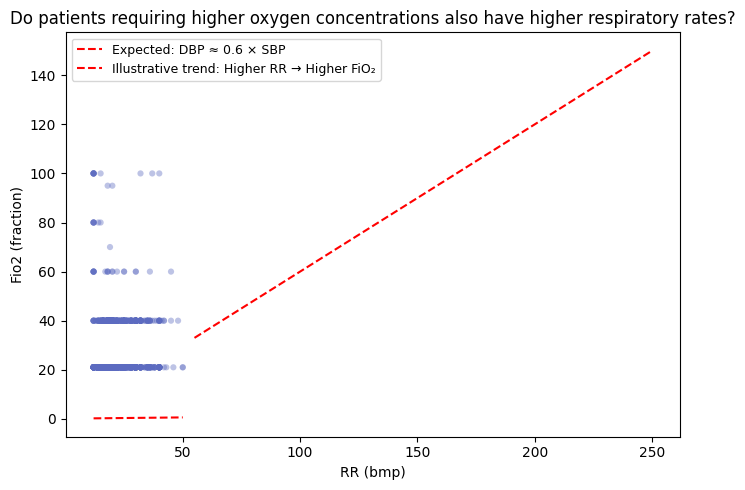

Saved: rr_vs_fio2.png


In [4]:
# Scatter plot: RR vs Fio2
fig, ax = plt.subplots(figsize=(7, 5))

scatter = ax.scatter(df['RR'], df['Fio2'],
                     alpha=0.4, s=20, color='#5C6BC0', edgecolors='none')

# Add a trend reference: DBP is typically ~2/3 of SBP
sbp_range = np.linspace(df['SBP'].min(), df['SBP'].max(), 100)
ax.plot(sbp_range, sbp_range * 0.6, color='red', linestyle='--',
        linewidth=1.5, label='Expected: DBP ≈ 0.6 × SBP')

# Add a trend reference: Higher RR may correspond to increasing oxygen requirement
rr_range = np.linspace(df['RR'].min(), df['RR'].max(), 100)
fio2_trend = 0.21 + (rr_range - 12) * 0.01
ax.plot(rr_range, fio2_trend,color='red', linestyle='--', linewidth=1.5, label='Illustrative trend: Higher RR → Higher FiO₂')

ax.set_title('Do patients requiring higher oxygen concentrations also have higher respiratory rates?', fontsize=12)
ax.set_xlabel('RR (bmp)')
ax.set_ylabel('Fio2 (fraction)')
ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig('rr_vs_fio2.png', dpi=100, bbox_inches='tight')
plt.show()
print("Saved: rr_vs_fio2.png")

In [5]:
# Always save plots before posting to Discord or GitHub
# Use dpi=100 for Discord (smaller file), dpi=150 for GitHub README

# Summary: all the plots we created today
import os
plot_files = [f for f in os.listdir('.') if f.endswith('.png')]
print("Plots saved in this session:")
for f in sorted(plot_files):
    size_kb = os.path.getsize(f) / 1024
    print(f"  {f:35s} ({size_kb:.0f} KB)")

Plots saved in this session:
  RR_histogram.png                    (35 KB)
  rr_vs_fio2.png                      (39 KB)
